<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#22회-통계분석" data-toc-modified-id="22회-통계분석-1">22회 통계분석</a></span><ul class="toc-item"><li><span><a href="#회사는-제품에-금속-재질-함유량의-분산이-1.3을-넘으면-불량이라고-판단한다.-회사에서는-품질경영팀으로부터-제조사별로-금속함유량이-차이가-난다고-제보를-받았다.-해당-금속함유량-데이터에-대한-검정을-수행하시오.-(유의확률:0.05)-" data-toc-modified-id="회사는-제품에-금속-재질-함유량의-분산이-1.3을-넘으면-불량이라고-판단한다.-회사에서는-품질경영팀으로부터-제조사별로-금속함유량이-차이가-난다고-제보를-받았다.-해당-금속함유량-데이터에-대한-검정을-수행하시오.-(유의확률:0.05)--1.1">회사는 제품에 금속 재질 함유량의 분산이 1.3을 넘으면 불량이라고 판단한다. 회사에서는 품질경영팀으로부터 제조사별로 금속함유량이 차이가 난다고 제보를 받았다. 해당 금속함유량 데이터에 대한 검정을 수행하시오. (유의확률:0.05) <br></a></span><ul class="toc-item"><li><span><a href="#연구가설과-귀무가설을-작성시오" data-toc-modified-id="연구가설과-귀무가설을-작성시오-1.1.1">연구가설과 귀무가설을 작성시오<br></a></span></li><li><span><a href="#가설을-양측-검정-" data-toc-modified-id="가설을-양측-검정--1.1.2">가설을 양측 검정 <br></a></span></li><li><span><a href="#검정통계량,-가설-채택" data-toc-modified-id="검정통계량,-가설-채택-1.1.3">검정통계량, 가설 채택<br></a></span></li></ul></li><li><span><a href="#200개의-Lot별-불량-제품-수량-데이터에-따라-아래의-값을-구하시오.-" data-toc-modified-id="200개의-Lot별-불량-제품-수량-데이터에-따라-아래의-값을-구하시오.--1.2">200개의 Lot별 불량 제품 수량 데이터에 따라 아래의 값을 구하시오. <br></a></span></li></ul></li></ul></div>

# 22회 통계분석 

## 회사는 제품에 금속 재질 함유량의 분산이 1.3을 넘으면 불량이라고 판단한다. 회사에서는 품질경영팀으로부터 제조사별로 금속함유량이 차이가 난다고 제보를 받았다. 해당 금속함유량 데이터에 대한 검정을 수행하시오. (유의확률:0.05) <br>
### 연구가설과 귀무가설을 작성시오<br>
### 가설을 양측 검정 <br>
### 검정통계량, 가설 채택<br>


In [1]:
import pandas as pd 
import numpy as np 
## 1.데이터 불러오기 
df = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/metalicity')
df

,metalicity
0,42.731551
1,46.429668
2,45.754023
3,45.808060
4,44.072529
...,...
145,45.915727
146,45.277868
147,45.082157
148,44.297235


"모분산이 1.3인가?"를 확인하는 카이제곱 검정을 수행해야 합니다. 파이썬 scipy에는 직접적인 함수가 없으므로 공식을 활용해야 합니다.

귀무가설($H_0$): 제품의 금속 재질 함유량 분산은 1.3이다. ($\sigma^2 = 1.3$)

대립가설($H_1$): 제품의 금속 재질 함유량 분산은 1.3이 아니다.
($\sigma^2 \neq 1.3$) (양측 검정 시)

In [2]:
from scipy.stats import chi2

# 2. 검정에 필요한 값들 계산
n = len(df)
sample_var = np.var(df['metalicity'], ddof=1) # 표본 분산 (자유도 1)
hypo_var = 1.3 # 귀무가설의 모분산

# 3. 카이제곱 검정 통계량 계산 공식: (n-1) * s^2 / sigma^2
chi_stat = (n - 1) * sample_var / hypo_var

# 4. p-value 계산 (양측 검정)
tail_prob = chi2.cdf(chi_stat, df=n-1)
p_val = 2 * min(tail_prob, 1 - tail_prob)

print(f"검정통계량: {chi_stat:.4f}, p-value: {p_val:.4f}")

검정통계량: 85.1823, p-value: 0.0000


결과: 유의확률($p\text{-value}$)이 유의수준 $0.05$보다 작으므로 귀무가설($H_0$)을 기각한다.

최종 결론: 유의수준 $0.05$ 하에서 제품의 금속 재질 함유량 분산이 1.3이라는 귀무가설을 기각하며, 금속 함유량의 분산은 1.3과 차이가 있다고 판단할 수 있다. 즉, 품질 기준을 충족하지 못하거나 변동성이 기준과 다르다는 제보가 타당하다고 볼 수 있다.


## 200개의 Lot별 불량 제품 수량 데이터에 따라 아래의 값을 구하시오. <br>
- p관리도 : 전체품목의 표본에서 부적합 부품의 수의 비율 
2.1 p관리도에 따라 관리중심선(center line), 관리 상한선, 하한선 구하시오<br>
2.2 관리도 시각화 하시오<br>



In [3]:
df2 = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/lot_quality.csv')
df2 = df2.set_index('lot')
df2

,생산수량,불량수량
lot,,
1,587,19
2,588,15
3,455,19
4,666,12
5,750,15
...,...,...
196,631,18
197,565,21
198,570,12


In [4]:
## 관리 중심선 : 전체 불량 비율 
CL = df2["불량수량"].sum() / df2["생산수량"].sum()
df2["p"] = df2["불량수량"]/df2["생산수량"]
df2["UCL"] = CL + (3 * (CL * (1 - CL) / df2["생산수량"])**0.5)
df2["LCL"] = CL - (3 * (CL * (1 - CL) / df2["생산수량"])**0.5)

# LCL이 0보다 작으면 0으로 처리하는 것이 일반적입니다.
df2["LCL"] = df2["LCL"].clip(lower=0)
print("관리중심선 : " , CL )
df2

관리중심선 :  0.029024320840935338


,생산수량,불량수량,p,UCL,LCL
lot,,,,,
1,587,19,0.032368,0.049811,0.008238
2,588,15,0.025510,0.049793,0.008255
3,455,19,0.041758,0.052635,0.005414
4,666,12,0.018018,0.048539,0.009509
5,750,15,0.020000,0.047414,0.010635
...,...,...,...,...,...
196,631,18,0.028526,0.049073,0.008975
197,565,21,0.037168,0.050212,0.007837
198,570,12,0.021053,0.050119,0.007930


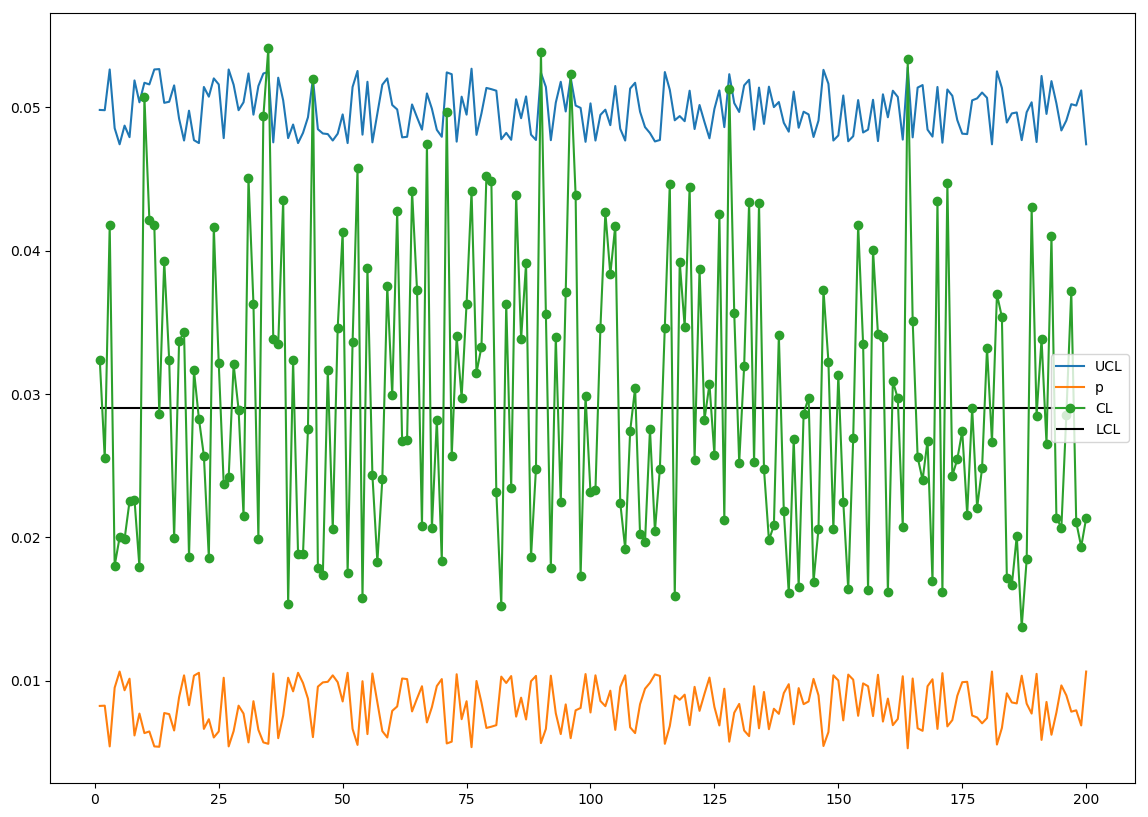

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize =(14, 10))
plt.plot(df2["UCL"])
plt.plot(df2["LCL"])
plt.plot(df2["p"],marker='o')
plt.hlines(CL,1, 200)
plt.legend(['UCL','p','CL','LCL'])



3.표에 제품 1, 2를 만드는데 재료 a, b, c가 일부 사용되며, 제품 1과 2를 만들 때 12만원과 18만원을 벌 수 있다. 재료는 한정적으로 주어지는데, 이때 최대 수익을 낼 수 있을 때의 제품 1과 제품2의 개수를 구하라.
재료 공급량 { a: 1300, b: 1000, c:1200 }(10점)


In [6]:
## 제품1 : x, 제품2 :y 
## y가 최대였을때(32개)부터 하나씩 줄여가며 최대값 갱신 

x=0 
y= 32

max_profit = 32*18 
material_a = 20
material_b = 40
material_c = 240

while((material_a > 0) or (material_b > 0) or( material_c > 0) ) :
    y-=1
    material_a += 40 
    material_b += 30
    material_c += 30 
    
    while ((material_a >= 20) and (material_b >= 20) and (material_c >= 20)) : 
        x+=1    
        material_a -= 20
        material_b -= 20
        material_c -= 20
        
        if (y*18 + x*12)>max_profit : 
            max_profit = (y*18 + x*12)
            result_x = x 
            result_y = y 
    
    if y==0: 
        break

print("최대 수익은 " , max_profit ,  " 만원 이다. ")
print("제품 1 수량 :  ", result_x)
print("제품 2 수량 :  ", result_y)

최대 수익은  600  만원 이다. 
제품 1 수량 :   5
제품 2 수량 :   30



4.상품 a와 b가 있을 때 다음과 같은 구매 패턴이 있다고 함. ['a','a','b','b','a','a','a','a','b','b','b','b','b','a','a','b','b','a','b','b']<br>
4.1 구매하는 패턴으로 봐서 두 상품이 연관이 있는지 가설 세우고 검정하시오<br>
4.2 연구가설 귀무가설 세우시오<br>
4.3 가설 채택하시오

귀무가설($H_0$): 상품 a와 b의 구매 패턴은 무작위적이다.\
대립가설($H_1$): 상품 a와 b의 구매 패턴은 무작위적이지 않다. (일정한 패턴이 있다.)

In [7]:
import pandas as pd 

data = ['a','a','b','b','a','a','a','a','b','b','b','b','b','a','a','b','b','a','b','b']
test_df = pd.DataFrame(data,columns=["product"])
test_df.loc[test_df['product']=='a','product'] = 1
test_df.loc[test_df['product']=='b','product'] = 0
test_df['product']

0     1
1     1
2     0
3     0
4     1
5     1
6     1
7     1
8     0
9     0
10    0
11    0
12    0
13    1
14    1
15    0
16    0
17    1
18    0
19    0
Name: product, dtype: object

In [8]:
from statsmodels.sandbox.stats.runs import runstest_1samp

runstest_1samp(test_df['product'])


(-1.1144881152070183, 0.26506984027306035)

분석결과: p-value가 0.265로 0.05보다 크므로 "귀무가설을 채택하여 구매 패턴이 무작위적이라고 판단한다"